In [1]:
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.compose import TransformedTargetRegressor


# Data Loade

In [2]:
from zipfile import ZipFile

In [3]:
zip_path = '/Users/mikkelpedersen/Desktop/project_vs_studio/random projekter/insurance.zip'

with ZipFile(zip_path, 'r') as insurance:
    file_list = insurance.namelist()
    print("Files in zip:", file_list)
    
    # Use the first CSV (adjust logic if multiple files exist)
    target_file = file_list[0]

    with insurance.open(target_file) as insurance_df:
        df = pd.read_csv(insurance_df)

Files in zip: ['insurance.csv']


# Data inspection

In [4]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [5]:
class DataPlotter():
    def __init__(self, Dataframe : pd.DataFrame):
        self.df = Dataframe
        
    def histogram(self, column):
        if column not in self.df:
            raise ValueError('The column does not exist in the dataframe')
        plt.figure(figsize=(10,6))
        sns.countplot(x=self.df[column])
        plt.title(f'Historgram of {column}')
        plt.show()
        print(self.df[column].value_counts())
        
        
    def scatter(self, x_column, y_column):
        if x_column not in self.df or y_column not in self.df:
            raise ValueError('The columns does not exist in the df')
        plt.figure(figsize=(10,6))
        sns.scatterplot(x=self.df[x_column], y=self.df[y_column])
        plt.title(f'Scatterplot of x: {x_column} and y: {y_column}')
        plt.xlabel(x_column)
        plt.ylabel(y_column)
        plt.show()
        
    def class_pairplot(self):
        plt.figure(figsize=(10,10))
        sns.pairplot(self.df)
        plt.show()
        display(self.df.describe())
        
        
    def box_plot(self, x_col, y_col):
        plt.figure(figsize=(10,5))
        sns.boxplot(x=self.df[x_col], y=self.df[y_col], medianprops={"color": "r", "linewidth": 2}, notch=True)
        plt.title(f'Boxplot of x: {x_col}, and y: {y_col}')
        plt.show()
        
        
    def info(self, val_count_col):
        display(self.df)
        print('-'*50)
        for col in self.df.select_dtypes(include=['float64', 'int64']):
            print(f' the mean of {col}: {round(self.df[col].mean(),2)}') 
        print('-'*50)
        print('The amount of missing values')
        print(self.df.isnull().sum())
        print('-'*50)
        print('Describe')
        display(self.df.describe())
        print('-'*50)
        print(f'Value counts for {col}')
        print(self.df[val_count_col].value_counts())

In [6]:
plotter = DataPlotter(df)

In [ ]:
df.info()

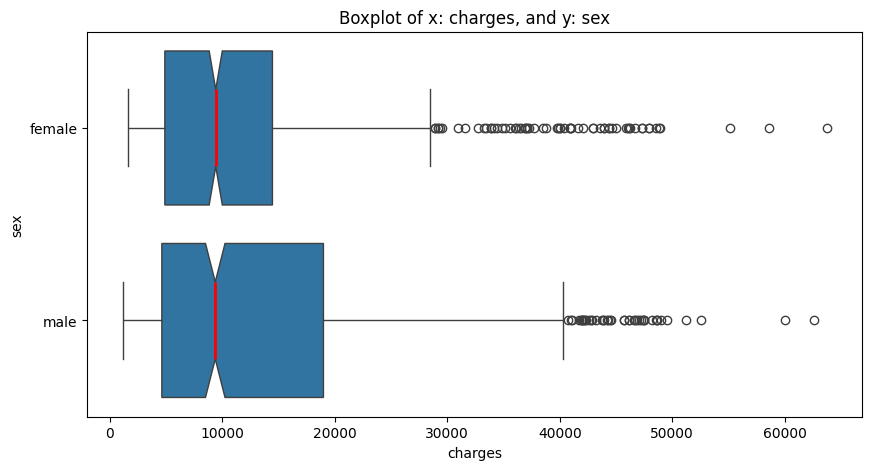

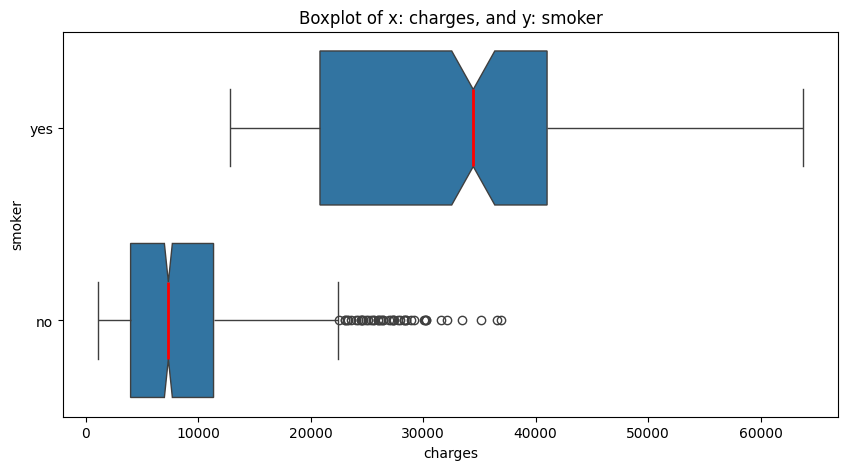

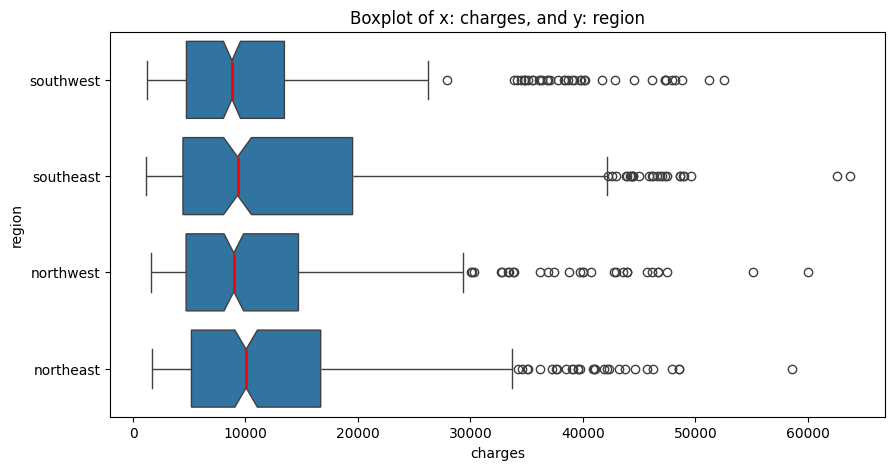

In [7]:
for i in df.select_dtypes(include=['object']):
    plotter.box_plot('charges', i)

In [ ]:
plotter.info('children')

In [ ]:
plotter.histogram('sex')

In [ ]:
plotter.scatter('bmi', 'charges')

In [ ]:
plotter.class_pairplot()

# Data Preprocessing

In [8]:
df_copy = df.copy(deep=True)
target_cop = df['charges']

In [9]:
print(df.select_dtypes(include='object')), print(df.select_dtypes(include=['int64', 'float64']))

         sex smoker     region
0     female    yes  southwest
1       male     no  southeast
2       male     no  southeast
3       male     no  northwest
4       male     no  northwest
...      ...    ...        ...
1333    male     no  northwest
1334  female     no  northeast
1335  female     no  southeast
1336  female     no  southwest
1337  female    yes  northwest

[1338 rows x 3 columns]
      age     bmi  children      charges
0      19  27.900         0  16884.92400
1      18  33.770         1   1725.55230
2      28  33.000         3   4449.46200
3      33  22.705         0  21984.47061
4      32  28.880         0   3866.85520
...   ...     ...       ...          ...
1333   50  30.970         3  10600.54830
1334   18  31.920         0   2205.98080
1335   18  36.850         0   1629.83350
1336   21  25.800         0   2007.94500
1337   61  29.070         0  29141.36030

[1338 rows x 4 columns]


(None, None)

In [10]:
class Preprocessing ():
    def __init__(self, DataFrame : pd.DataFrame):
        self.df = DataFrame
        self.scaler = StandardScaler()
        self.encoder = OneHotEncoder(sparse_output=False)
        
    def numeric_prepors(self):
        num_cols = self.df.select_dtypes(include=['float64', 'int64']).columns
        num_cols = [col for col in num_cols if col != 'charges']
        self.df[num_cols] = self.scaler.fit_transform(self.df[num_cols])
        print('Numeric columns sclaed')
        display(self.df[num_cols].head())         
        
        
    def categorical_prepors(self):
        cat_col = self.df.select_dtypes(include='object').columns
        # Fit and transform the categorical columns
        encoded = self.encoder.fit_transform(self.df[cat_col])
        encoded_df = pd.DataFrame(
            encoded,
            columns=self.encoder.get_feature_names_out(cat_col),
            index=self.df.index
        )

        # Drop original categorical columns and concatenate encoded ones
        self.df.drop(columns=cat_col, inplace=True)
        self.df = pd.concat([self.df, encoded_df], axis=1)
        print('Categorical encoded columns:')
        display(self.df.head(10))   
    
    def get_df(self):
        return self.df

In [11]:
preprocessor = Preprocessing(df)

In [12]:
preprocessor.numeric_prepors()
preprocessor.categorical_prepors()
df = preprocessor.get_df()

Numeric columns sclaed


,age,bmi,children
0,-1.438764,-0.453320,-0.908614
1,-1.509965,0.509621,-0.078767
2,-0.797954,0.383307,1.580926
3,-0.441948,-1.305531,-0.908614
4,-0.513149,-0.292556,-0.908614


Categorical encoded columns:


,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,16884.92400,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.509965,0.509621,-0.078767,1725.55230,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-0.797954,0.383307,1.580926,4449.46200,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.441948,-1.305531,-0.908614,21984.47061,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.513149,-0.292556,-0.908614,3866.85520,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
5,-0.584350,-0.807656,-0.908614,3756.62160,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6,0.483668,0.455486,-0.078767,8240.58960,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7,-0.157143,-0.479567,1.580926,7281.50560,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8,-0.157143,-0.136714,0.751079,6406.41070,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
9,1.480485,-0.791252,-0.908614,28923.13692,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [13]:
df.head(10)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,-0.453320,-0.908614,16884.92400,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-1.509965,0.509621,-0.078767,1725.55230,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-0.797954,0.383307,1.580926,4449.46200,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.441948,-1.305531,-0.908614,21984.47061,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.513149,-0.292556,-0.908614,3866.85520,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
5,-0.584350,-0.807656,-0.908614,3756.62160,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6,0.483668,0.455486,-0.078767,8240.58960,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7,-0.157143,-0.479567,1.580926,7281.50560,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
8,-0.157143,-0.136714,0.751079,6406.41070,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
9,1.480485,-0.791252,-0.908614,28923.13692,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


# Models

In [14]:
X = df.drop(columns='charges')
y = df['charges']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
class Models:
    def __init__(self, X_train, y_train, X_test, y_test):
        self.X_train = X_train
        self.y_train = y_train.to_numpy().reshape(-1, 1)
        self.X_test = X_test
        self.y_test = y_test.to_numpy().reshape(-1, 1)
        self.target_scaler = StandardScaler()
        
        # Base models
        self.models = {
            'LinearRegression': LinearRegression(),
            'Ridge': Ridge(),
            'DecisionTree': DecisionTreeRegressor(random_state=42),
            'RandomForest': RandomForestRegressor(random_state=42),
            'GradientBoosting': GradientBoostingRegressor(random_state=42)
        }

        # parameter grids
        self.param_grids = {
            'DecisionTree': {
                'max_depth': [None, 5, 10, 20],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'criterion': ['squared_error', 'friedman_mse', 'absolute_error']
            },
            'RandomForest': {
                'n_estimators': [100, 200],
                'max_depth': [None, 10, 20],
                'min_samples_split': [2, 5],
                'min_samples_leaf': [1, 2],
                'bootstrap': [True, False]
            },
            'GradientBoosting': {
                'n_estimators': [100, 200],
                'learning_rate': [0.01, 0.1],
                'max_depth': [3, 5],
                'min_samples_split': [2, 5],
                'min_samples_leaf': [1, 2],
                'subsample': [0.8, 1.0]
            }
        }

        self.trained_models = {}
        self.results = {}

    def model_grid_search(self):
        y_scaled = self.target_scaler.fit_transform(self.y_train)
        for name, model in self.models.items():
            if name in self.param_grids:
                print(f"Performing grid search for {name}")
                grid_search = GridSearchCV(
                    model,
                    self.param_grids[name],
                    cv=10,
                    scoring='neg_mean_absolute_error',
                    n_jobs=-1
                )
                grid_search.fit(self.X_train, y_scaled.ravel())  # flatten target for sklearn
                best_model = grid_search.best_estimator_
                self.models[name] = best_model
                print(f"Best params for {name}: {grid_search.best_params_}")
            else:
                print(f"No grid search for {name}, using default parameters")
        
        print("Grid search complete.\n")

    def train_all(self):
        y_scaled = self.target_scaler.transform(self.y_train)  # Don't refit here
        for name, model in self.models.items():
            model.fit(self.X_train, y_scaled.ravel())
            self.trained_models[name] = model
            y_pred_scaled = model.predict(self.X_test).reshape(-1, 1)
            print(y_pred_scaled)
            y_pred = self.target_scaler.inverse_transform(y_pred_scaled)
            print(y_pred)
            mae = mean_absolute_error(self.y_test, y_pred)
            mape = mean_absolute_percentage_error(self.y_test, y_pred)
            r2 = r2_score(self.y_test, y_pred)
            
            self.results[name] = {
                'mae': mae,
                'mape': mape,
                'r2': r2
            }

        print("Model training and evaluation complete.\n")
        

    def model_evaluation(self):
        print('Model evaluation result')
        for name, metric in self.results.items():
            print(f"Model: {name}, MAE: {metric['mae']:.3f}, MAPE: {metric['mape']:.3f}, R2 Score: {metric['r2']:.3f}")
        return self.results

    def plot_predictions(self, model_name):
        if model_name not in self.trained_models:
            raise ValueError(f"{model_name} is not trained or does not exist.")
        model = self.trained_models[model_name]
        y_pred_scaled = model.predict(self.X_test).reshape(-1, 1)
        y_pred = self.target_scaler.inverse_transform(y_pred_scaled)
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=self.y_test.ravel(), y=y_pred.ravel())
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"{model_name} Predictions")
        plt.plot([self.y_test.min(), self.y_test.max()], [self.y_test.min(), self.y_test.max()], 'r--')
        plt.show()


In [24]:
model_manager = Models(X_train, y_train, X_test, y_test)

In [26]:
model_manager.model_grid_search()

No grid search for LinearRegression, using default parameters
No grid search for Ridge, using default parameters
Performing grid search for DecisionTree
Best params for DecisionTree: {'criterion': 'absolute_error', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Performing grid search for RandomForest
Best params for RandomForest: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Performing grid search for GradientBoosting
Best params for GradientBoosting: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 1.0}
Grid search complete.



In [28]:
model_manager.train_all()
results = model_manager.model_evaluation()

[[-0.328125 ]
 [-0.5078125]
 [ 1.890625 ]
 [-0.3125   ]
 [ 1.0625   ]
 [-0.1875   ]
 [-1.09375  ]
 [ 0.3125   ]
 [-1.       ]
 [-0.1640625]
 [ 1.15625  ]
 [-0.3203125]
 [-0.6640625]
 [ 2.0234375]
 [ 2.171875 ]
 [ 1.90625  ]
 [ 0.1796875]
 [ 1.8125   ]
 [-0.34375  ]
 [ 1.4453125]
 [-0.78125  ]
 [-0.25     ]
 [-0.90625  ]
 [-0.484375 ]
 [-0.1484375]
 [ 0.       ]
 [ 0.125    ]
 [-0.578125 ]
 [-0.25     ]
 [-0.9375   ]
 [-0.328125 ]
 [ 0.       ]
 [-0.71875  ]
 [-0.8125   ]
 [-0.734375 ]
 [ 0.       ]
 [-0.9296875]
 [-0.359375 ]
 [ 1.59375  ]
 [ 1.53125  ]
 [-0.7578125]
 [-0.75     ]
 [ 0.09375  ]
 [-0.15625  ]
 [-0.375    ]
 [-0.09375  ]
 [-0.65625  ]
 [-0.828125 ]
 [ 1.7734375]
 [-0.34375  ]
 [ 0.21875  ]
 [-0.921875 ]
 [-0.0546875]
 [-0.96875  ]
 [ 0.0078125]
 [-0.03125  ]
 [-0.734375 ]
 [ 1.5      ]
 [ 0.0234375]
 [ 0.       ]
 [ 0.09375  ]
 [-0.21875  ]
 [ 0.2734375]
 [-0.453125 ]
 [-0.09375  ]
 [-0.7578125]
 [ 1.046875 ]
 [-0.203125 ]
 [-0.921875 ]
 [-0.578125 ]
 [-0.1875   ]
 [-0.1

In [59]:
df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

In [60]:
df

,Model,mae,mape,r2
0,LinearRegression,4213.684271,0.446225,0.768429
1,Ridge,4151.383711,0.436943,0.769503
2,DecisionTree,1841.151954,0.144907,0.848790
3,RandomForest,2481.640562,0.291400,0.866154
4,GradientBoosting,2476.225223,0.285088,0.867308


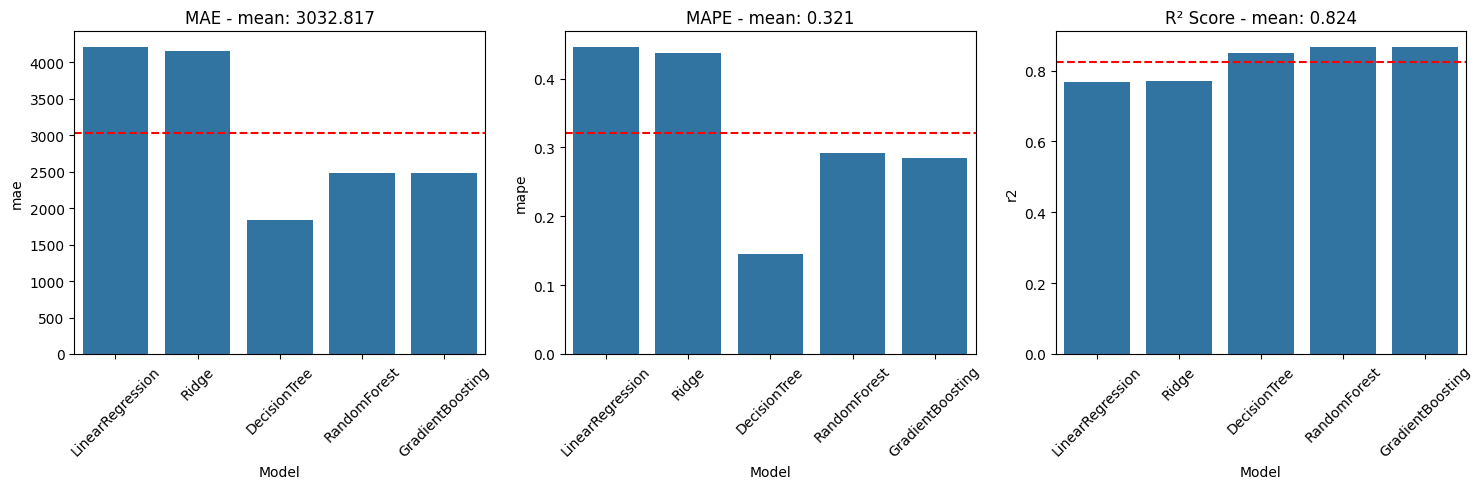

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

mae_mean = df['mae'].mean()
sns.barplot(data=df, x='Model', y='mae', ax=axes[0])
axes[0].set_title(f'MAE - mean: {mae_mean:.3f}')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(mae_mean, color='red', linestyle='--')

mape_mean = df['mape'].mean()
sns.barplot(data=df, x='Model', y='mape', ax=axes[1])
axes[1].set_title(f'MAPE - mean: {mape_mean:.3f}')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(mape_mean, color='red', linestyle='--')


r2_mean = df['r2'].mean()
sns.barplot(data=df, x='Model', y='r2', ax=axes[2])
axes[2].set_title(f'R² Score - mean: {r2_mean:.3f}')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(r2_mean, color='red', linestyle='--')


plt.tight_layout()
plt.show()

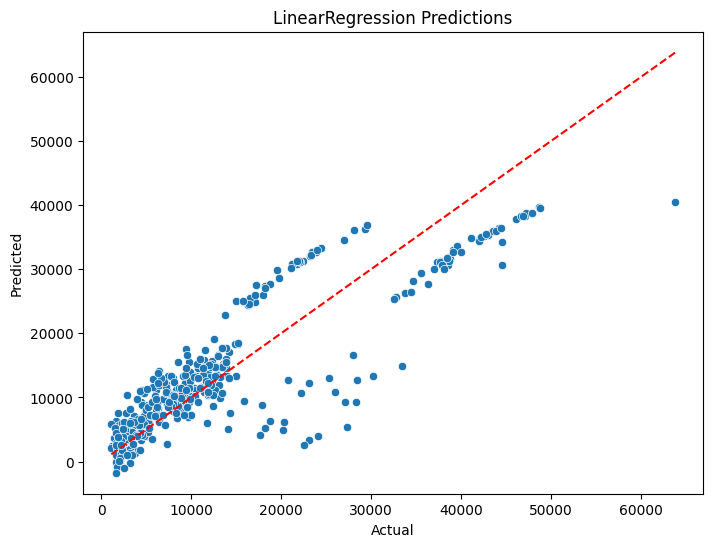

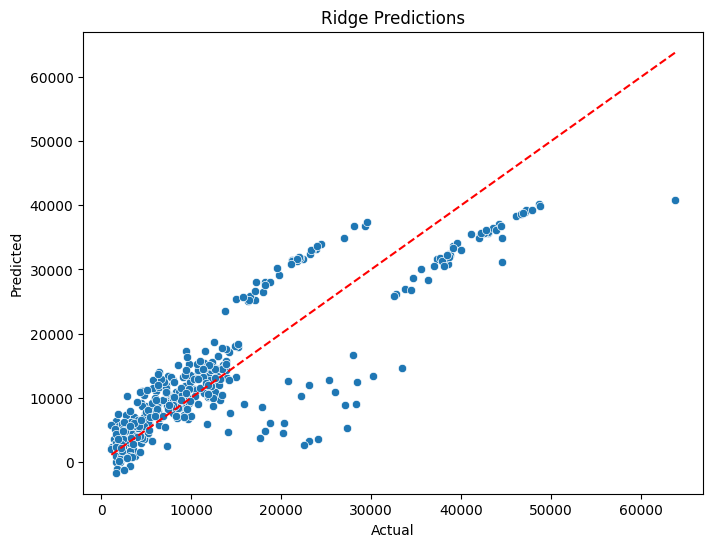

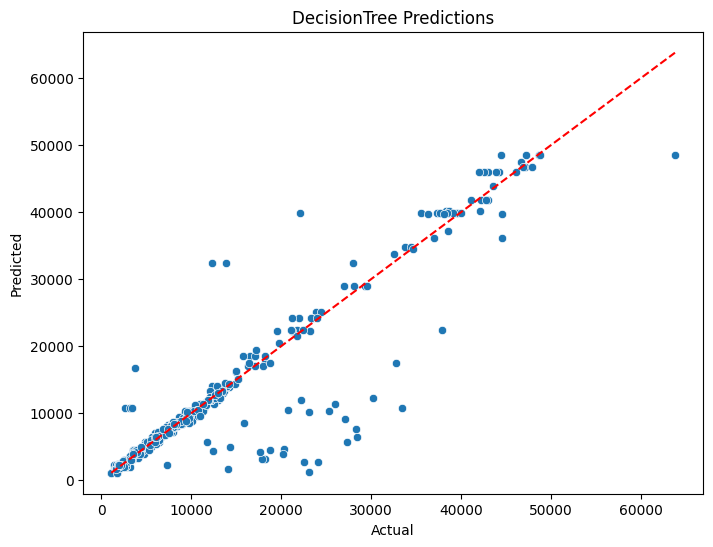

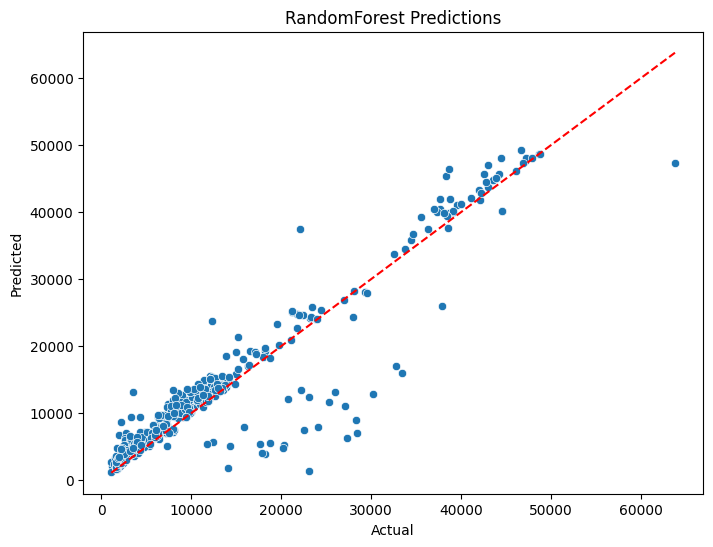

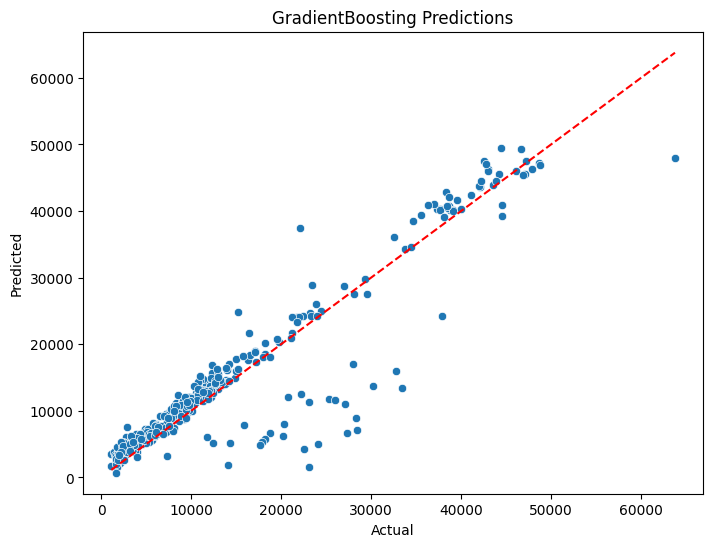

In [89]:
models_trained = ['LinearRegression', 'Ridge', 'DecisionTree', 'RandomForest', 'GradientBoosting']
for model in models_trained:
    model_manager.plot_predictions(model)